### Import Packages

In [1]:
# General data handling
import pandas as pd
import numpy as np
import duckdb
import sklearn

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Sentence Transformers
import transformers
from sentence_transformers import SentenceTransformer

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV

# Validation 
from sklearn.model_selection import (StratifiedKFold, GridSearchCV, RandomizedSearchCV,
                                     cross_validate, cross_val_predict, train_test_split)
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             PrecisionRecallDisplay,
                             auc, make_scorer, recall_score, precision_score)

# Other helpers
from scipy.stats import loguniform
import joblib
from tqdm import tqdm

c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load the data

In [2]:
# Connect to DuckDB database
db = duckdb.connect(database='publications.db')

In [3]:
# Convert raw data to pandas dataframe
data = db.sql("SELECT * FROM publications_raw").df()

In [5]:
# Concatenate title and abstract for input into sentence transformer
data['text'] = data['title'] + ' [SEP] ' + data['abstract']

In [4]:
# inspect data
print(len(data))
data.head()

4815


,id,title,abstract,year,scope,pillar,research_category,truncated,stratify_label
0,pub.1192791591,Mushroom: an emerging source for next generati...,"Background: In recent years, plant-based and a...",2025,in,PB,Ingredient optimisation,False,PB-Ingredient optimisation
1,pub.1187762379,Plant-Based Alternatives to Meat Products,Animal proteins have been used in the formulat...,2025,in,PB,Other,False,PB-Other
2,pub.1193391974,Influence of processing on protein quality and...,While meat is an established source of high-qu...,2025,in,PB,Ingredient optimisation,False,PB-Ingredient optimisation
3,pub.1188899046,Solid State Fermentation—A Promising Approach ...,The increasing demand for sustainable dietary ...,2025,in,F,Other,False,F-Other
4,pub.1193352421,"Physicochemical, Microbiological and Sensory E...",The bioactive properties of a phenolic extract...,2025,in,PB,End product formulation,False,End product formulation


### Sentence Transformer to generate text embeddings

In [ ]:
# # Load base model and tokenizer
# tokenizer = AutoTokenizer.from_pretrained('allenai/specter2_base')
# model = AutoAdapterModel.from_pretrained('allenai/specter2_base')

# # Load classification adapter
# model.load_adapter("allenai/specter2_classification", 
#                    source="hf", 
#                    load_as="specter2_cls", 
#                    set_active=True)
# model.eval()

In [10]:
# Check token lengths
# Access tokenizer from within the loaded SentenceTransformer
tokenizer = model.tokenizer

# Count tokens for each text (title + abstract combined)
token_count = data['text'].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)

# Summary statistics
print(token_count.describe())
print(f"\nTexts exceeding 512 tokens: {(token_count > 512).sum()} "
      f"({(token_count > 512).mean():.1%})")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (549 > 512). Running this sequence through the model will result in indexing errors


count    4815.000000
mean      345.041952
std       110.430074
min        30.000000
25%       277.000000
50%       331.000000
75%       392.000000
max      1671.000000
Name: text, dtype: float64

Texts exceeding 512 tokens: 297 (6.2%)


In [ ]:
# Visualise distribution
token_count.hist(bins=50, edgecolor='black')
plt.axvline(512, color='red', linestyle='--', label='Token limit (512)')
plt.xlabel('Token count')
plt.ylabel('Number of publications')
plt.title('Token length distribution')
plt.legend()
plt.show()

In [14]:
# Leave entries with excessively long token counts for now, they will be automatically truncated by the model
# Store information about truncation in the dataset to check these entries later
data['truncated'] = token_count > 512

0       False
1       False
2       False
3       False
4       False
        ...  
4810    False
4811    False
4812    False
4813    False
4814    False
Name: truncated, Length: 4815, dtype: bool


In [ ]:
# Create combined label for stratification
# data['stratify_label'] = data['pillar'] + '-' + data['research_category']

# # For labels that are too rare, only group them by research category across pillars 
# counts = data['stratify_label'].value_counts()
# rc = counts.index[counts < 4].str.split('-').str[1].unique()

# data['stratify_label'] = data['stratify_label'].where(
#     ~data['research_category'].isin(rc), data['stratify_label'].str.split('-').str[1]
# )

In [ ]:
# data['stratify_label'].value_counts()

In [ ]:
# add the truncated label to database
# db.sql("ALTER TABLE publications_raw ADD COLUMN IF NOT EXISTS truncated BOOLEAN")

# db.register("df_temp", data)  
# db.sql("""
#     UPDATE publications_raw
#     SET truncated = df_temp.truncated
#     FROM df_temp
#     WHERE publications_raw.id = df_temp.id
# """)

In [ ]:
# add the stratify_label to database
# db.sql("ALTER TABLE publications_raw ADD COLUMN IF NOT EXISTS stratify_label TEXT")

# db.register("df_temp", data)  
# db.sql("""
#     UPDATE publications_raw
#     SET stratify_label = df_temp.stratify_label
#     FROM df_temp
#     WHERE publications_raw.id = df_temp.id
# """)

In [6]:
db.sql("DESCRIBE publications_raw").show()

┌───────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name    │ column_type │  null   │   key   │ default │  extra  │
│      varchar      │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ id                │ VARCHAR     │ NO      │ PRI     │ NULL    │ NULL    │
│ title             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ abstract          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ year              │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ scope             │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ pillar            │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ research_category │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ truncated         │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ stratify_label    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
└───────────

In [109]:
# for testing: subset data
# the following line of code subsets randomly
# data_sub = data.sample(n=500, random_state=42)

# but we want the classes to be represented somewhat balanced in the subset
data_sub = data.groupby('stratify_label').sample(frac=0.1, replace=False, random_state=42)

# manually add entries for labels with only 1 entry
# find labels with only 1 sample
rare = data_sub['stratify_label'].value_counts()
rare = rare[rare < 2].index

# Add 1 more from unsampled rows for those labels
extra = (
    data[~data.index.isin(data_sub.index) & data['stratify_label'].isin(rare)]
    .groupby('stratify_label')
    .sample(n=1, random_state=42)
)

# add together
data_sub = pd.concat([data_sub, extra])

print(len(data_sub))
print(data_sub['stratify_label'].value_counts())

490
stratify_label
NA-NA                         377
PB-Ingredient optimisation     28
End product formulation        15
Consumer & market research     13
Texturization methods           6
PB-Health & nutrition           5
F-Ingredient optimisation       4
Food safety & quality           4
PB-Crop development             4
Bioprocess design               3
F-Feedstocks                    3
CC-Health & nutrition           2
CC-Ingredient optimisation      2
CC-Other                        2
CM-Cell culture media           2
CM-Cell line development        2
CM-Other                        2
CM-Scaffolding                  2
F-Health & nutrition            2
F-Impact assessments            2
F-Other                         2
F-Strain development            2
PB-Impact assessments           2
PB-Other                        2
PB-Strain development           2
Name: count, dtype: int64


In [ ]:
# save to database to enable loading later
# db.sql("CREATE OR REPLACE TABLE publications_subset AS SELECT * FROM data_sub")

In [ ]:
# Function to encode publications
def get_embeddings(texts, batch_size=32):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True,
                          max_length=512, return_tensors='pt')
        with torch.no_grad():
            outputs = model(**inputs)
        # CLS token as document embedding
        embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(embeddings.numpy())
        
    return np.vstack(all_embeddings)

In [ ]:
# embeddings = get_embeddings(data['text'].tolist())

In [ ]:
# save embeddings
# np.save('specter_embeddings_test.npy', embeddings)

### Split data into train and test data

In [7]:
# Load embeddings 
embeddings = np.load('specter_embeddings.npy')

# Load subsetted data
# data_sub = db.sql("SELECT * FROM publications_subset").df()

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, data,
    test_size=0.2,
    random_state=42,
    stratify=data['stratify_label']
)


### Classification of in/out of scope

In [9]:
# Convert scope to binary integer class
y_train_scope = (y_train['scope'] == 'in').astype(int)
y_test_scope  = (y_test['scope']  == 'in').astype(int)

#### Test hyperparameters and models

In [10]:
# Set up validation metrics
## specificity isn't natively integrated, define function:
specificity_scorer = make_scorer(recall_score, pos_label=0)
npv_scorer = make_scorer(precision_score, pos_label=0)

scoring = {
    'precision':    'precision', # = TP / (TP + FP)
    'recall':       'recall', # = sensitivity = TP / (TP + FN)
    'specificity':  specificity_scorer, # = TN / (TN + FP)
    'npv':          npv_scorer, # = TN / (TN + FN)
    'f1':           'f1' # 2 × (precision × recall) / (precision + recall)
}

In [11]:
# Test hyperparameters of Logistic Regression model using cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'class_weight': ['balanced', None],
    'penalty': [None, 'l2']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
                    param_grid, cv=cv, scoring=scoring, refit='npv', n_jobs=-1)
grid.fit(X_train, y_train_scope)
print(grid.best_params_)

c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


{'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2'}


In [ ]:
# save results to data frame
lr_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_C', 'param_penalty',  
        'mean_test_precision', 'std_test_precision','mean_test_recall', 'std_test_recall', 'mean_test_f1', 'std_test_f1',
        'mean_test_specificity', 'std_test_specificity', 'mean_test_npv', 'std_test_npv']
lr_grid[cols]

## class_weight is clearly better with class_weight = 'balanced'
## the best C = 0.1

lr_grid[cols].to_csv('SPECTER_LR_grid.csv')

In [19]:
cols = ['param_C', 'param_penalty',  
        'mean_test_precision', 'std_test_precision','mean_test_recall', 'std_test_recall', 'mean_test_f1', 'std_test_f1',
        'mean_test_specificity', 'std_test_specificity', 'mean_test_npv', 'std_test_npv']
lr_grid[cols].sort_values('mean_test_npv', ascending=False)

,param_C,param_penalty,mean_test_precision,std_test_precision,mean_test_recall,std_test_recall,mean_test_f1,std_test_f1,mean_test_specificity,std_test_specificity,mean_test_npv,std_test_npv
1,0.1,l2,0.650037,0.032085,0.837934,0.013669,0.731457,0.017348,0.874465,0.018840,0.951397,0.003326
5,1.0,l2,0.674320,0.040489,0.806731,0.022464,0.733534,0.021859,0.891029,0.021673,0.943605,0.005612
9,10.0,l2,0.667046,0.047518,0.749073,0.038711,0.704431,0.032678,0.895337,0.022269,0.928324,0.010376
7,1.0,l2,0.758822,0.032163,0.711882,0.035252,0.733784,0.023506,0.937068,0.011553,0.921896,0.008649
3,0.1,l2,0.813926,0.037785,0.705865,0.023024,0.755464,0.021733,0.954953,0.011439,0.921701,0.005588
11,10.0,l2,0.696702,0.046188,0.713058,0.036051,0.703739,0.031453,0.913222,0.018728,0.920293,0.009401
13,100.0,l2,0.649392,0.048876,0.713037,0.038142,0.678585,0.034183,0.892357,0.021706,0.918594,0.010107
17,1000.0,l2,0.658189,0.039726,0.702236,0.042257,0.678677,0.032683,0.898648,0.016506,0.916351,0.011174
15,100.0,l2,0.654437,0.049643,0.702222,0.040472,0.676333,0.035230,0.896332,0.021161,0.916135,0.010733
0,0.1,NaN,0.665932,0.039506,0.695008,0.043451,0.679105,0.030697,0.902955,0.016871,0.914909,0.011052


In [13]:
# Test hyperparameters of Support Vector Classification model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'estimator__C':     [1, 10, 100, 1000],
    'estimator__gamma': [0.001, 0.01],
    'estimator__kernel': ['linear', 'rbf']
}

# CalibratedClasssifierCV wrapper to get calibrated probabilities
calibrated_svc = CalibratedClassifierCV(
    SVC(class_weight='balanced'),
    cv=cv,
    ensemble=False
)

grid = GridSearchCV(calibrated_svc, param_grid, cv=cv, scoring=scoring, refit='f1', n_jobs=-1)
grid.fit(X_train, y_train_scope)
print(grid.best_params_)

{'estimator__C': 10, 'estimator__gamma': 0.001, 'estimator__kernel': 'rbf'}


In [ ]:
# save results to data frame
svc_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_estimator__C', 'param_estimator__gamma', 'param_estimator__kernel', 
        'mean_test_precision', 'std_test_precision','mean_test_recall', 'std_test_recall', 'mean_test_f1', 'std_test_f1',
        'mean_test_specificity', 'std_test_specificity', 'mean_test_npv', 'std_test_npv']
svc_grid[cols]

svc_grid[cols].to_csv('SPECTER_SVC_grid.csv')

## best results for NPV, Recall and F1
## C=10, kernel='rbf', gamma=0.001

In [22]:
cols = ['param_estimator__C', 'param_estimator__gamma', 'param_estimator__kernel', 
        'mean_test_precision','mean_test_recall', 'mean_test_f1',
        'mean_test_specificity', 'mean_test_npv']
svc_grid[cols].sort_values('mean_test_npv', ascending=False)

,param_estimator__C,param_estimator__gamma,param_estimator__kernel,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_specificity,mean_test_npv
5,10,0.001,rbf,0.806266,0.719068,0.759193,0.951973,0.924857
9,100,0.001,rbf,0.826348,0.696205,0.755077,0.959589,0.919796
1,1,0.001,rbf,0.774017,0.686653,0.727089,0.944352,0.916202
7,10,0.010,rbf,0.824685,0.665039,0.735481,0.960584,0.912315
11,100,0.010,rbf,0.823217,0.665060,0.735091,0.960252,0.912267
15,1000,0.010,rbf,0.823217,0.665060,0.735091,0.960252,0.912267
13,1000,0.001,rbf,0.791924,0.662615,0.720772,0.951639,0.910990
3,1,0.010,rbf,0.786316,0.654231,0.713232,0.950646,0.908933
0,1,0.001,linear,0.763533,0.625395,0.686538,0.946012,0.901617
2,1,0.010,linear,0.763533,0.625395,0.686538,0.946012,0.901617


In [23]:
# Test hyperparameters of Multi-Layer Perceptron model
param_dist = {
    'hidden_layer_sizes': [(64,), (128,), (256,), (64, 32), (128, 64), (256, 128)],
    'alpha': loguniform(1e-5, 1e-2),
    'learning_rate_init': loguniform(1e-4, 1e-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = RandomizedSearchCV(
    MLPClassifier(early_stopping=True, random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring=scoring,
    refit='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

grid.fit(X_train, y_train_scope)
print(grid.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'alpha': np.float64(0.00011719079872167656), 'hidden_layer_sizes': (256, 128), 'learning_rate_init': np.float64(0.0002138729075414894)}


In [ ]:
# save results to data frame
mlp_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_hidden_layer_sizes', 'param_learning_rate_init', 
        'param_alpha', 
        'mean_test_precision', 'std_test_precision','mean_test_recall', 'std_test_recall', 'mean_test_f1', 'std_test_f1',
        'mean_test_specificity', 'std_test_specificity', 'mean_test_npv', 'std_test_npv']

mlp_grid[cols].to_csv('SPECTER_MLP_grid.csv')

## Best results for NPV & Recall (and third for F1)
## hidden_layer_sizes= (256,128), learning_rate_init=0.001490, alpha=0.000013 

In [29]:
cols = ['param_hidden_layer_sizes', 'param_learning_rate_init', 
        'param_alpha', 
        'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 
        'mean_test_specificity', 'mean_test_npv']

mlp_grid[cols].sort_values('mean_test_npv', ascending=False)

,param_hidden_layer_sizes,param_learning_rate_init,param_alpha,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_specificity,mean_test_npv
16,"(256, 128)",0.001490,0.000013,0.746121,0.750271,0.747750,0.929448,0.931086
31,"(256, 128)",0.000945,0.000016,0.769399,0.739535,0.752651,0.937733,0.928971
45,"(256, 128)",0.000214,0.000117,0.792900,0.727538,0.758111,0.947337,0.926576
14,"(128,)",0.011290,0.000011,0.756281,0.725186,0.738185,0.933762,0.925088
6,"(256, 128)",0.000105,0.000082,0.809425,0.713109,0.757200,0.952965,0.923383
21,"(256, 128)",0.000387,0.001520,0.793878,0.713159,0.750369,0.948330,0.923061
42,"(256, 128)",0.002342,0.000795,0.777491,0.709307,0.733204,0.940714,0.922621
24,"(64, 32)",0.004247,0.007866,0.794641,0.710670,0.750004,0.948993,0.922415
17,"(64, 32)",0.000861,0.000035,0.783076,0.709480,0.743381,0.945678,0.922090
44,"(128,)",0.000232,0.000415,0.785750,0.707171,0.742491,0.945680,0.921500


### Validate models with selected hyperparameters

### Logistic Regression

#### Cross validation

In [30]:
# Logistic Regression with C=10 and penalty='l2'
clf = LogisticRegression(max_iter=1000, class_weight='balanced', C=0.1, penalty='l2', random_state=42)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [31]:
# fit model
clf.fit(X_train, y_train_scope)

# Run cross-validation on subset of data
lr_results = cross_validate(clf, X_train, y_train_scope, cv=cv, scoring=scoring)

c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Public\minicond

In [32]:
for metric in ['precision', 'recall', 'specificity', 'npv', 'f1']:
    scores = lr_results[f'test_{metric}']
    print(f"{metric:12s}: {scores.mean():.3f} ± {scores.std():.3f}")

precision   : 0.650 ± 0.032
recall      : 0.838 ± 0.014
specificity : 0.874 ± 0.019
npv         : 0.951 ± 0.003
f1          : 0.731 ± 0.017


In [33]:
# Get prediction (out of fold)
lr_probs = cross_val_predict(clf, X_train, y_train_scope, 
                              cv=cv, method='predict_proba')[:, 1]
lr_preds = (lr_probs >= 0.5).astype(int)  # binary at default threshold


c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Public\minicond

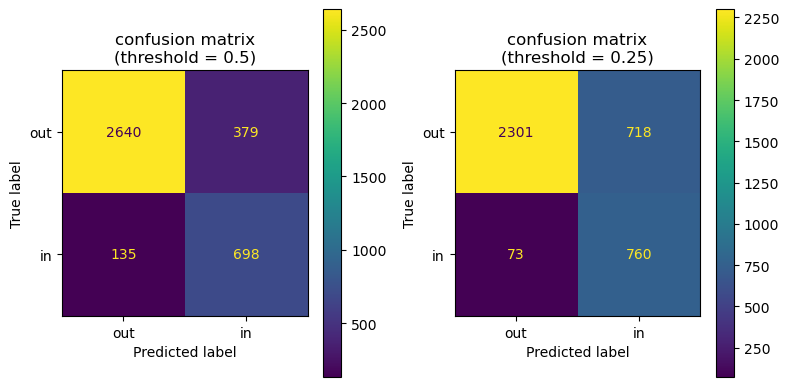

In [34]:
lr_preds_05 = (lr_probs >= 0.5).astype(int)  # binary at default threshold
lr_preds_025 = (lr_probs >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, lr_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, lr_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.show()

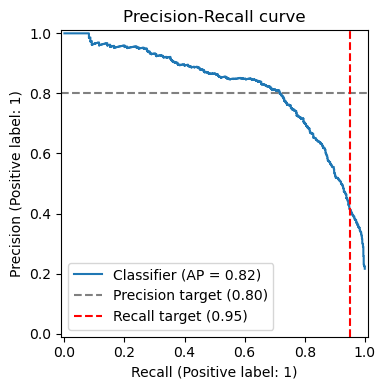

In [35]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_train_scope, lr_probs, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.show()

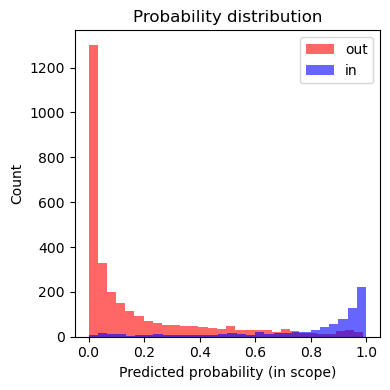

In [36]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(lr_probs[y_train_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(lr_probs[y_train_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.show()

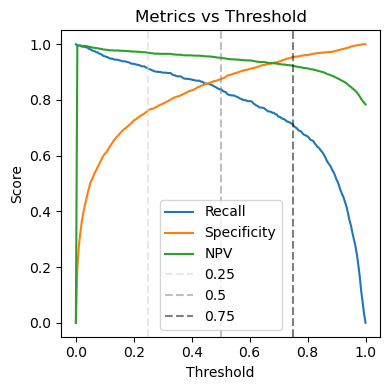

In [37]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    y_pred = (lr_probs >= t).astype(int)
    
    TP = ((y_pred == 1) & (y_train_scope == 1)).sum()
    TN = ((y_pred == 0) & (y_train_scope == 0)).sum()
    FP = ((y_pred == 1) & (y_train_scope == 0)).sum()
    FN = ((y_pred == 0) & (y_train_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(4, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
#plt.savefig('threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### Test data

In [38]:
# Test data
lr_test_pred = clf.predict(X_test)
lr_test_proba = clf.predict_proba(X_test)[:, 1]

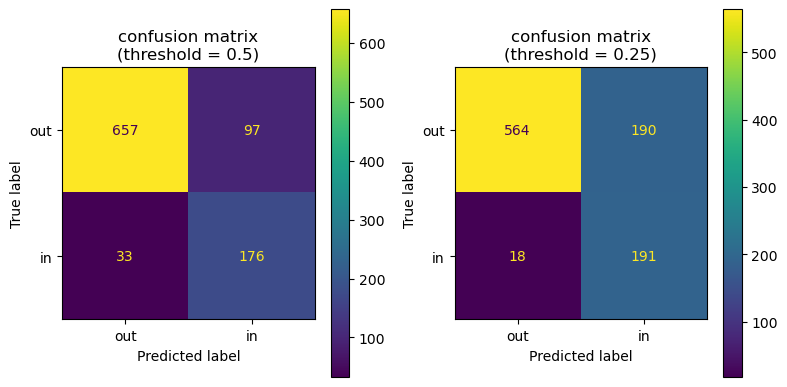

In [39]:
lr_test_preds_05 = (lr_test_proba >= 0.5).astype(int)  # binary at default threshold
lr_test_preds_025 = (lr_test_proba >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, lr_test_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, lr_test_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.savefig('Plots/SPECTER_LR_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

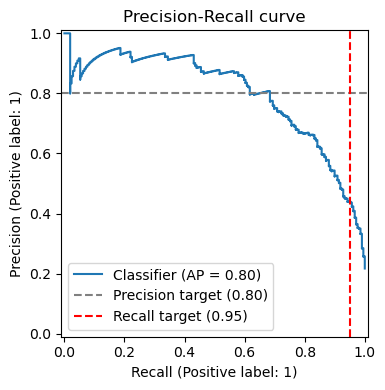

In [40]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_test_scope, lr_test_proba, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/SPECTER_LR_Precision-Recall.png', dpi=150, bbox_inches='tight')
plt.show()

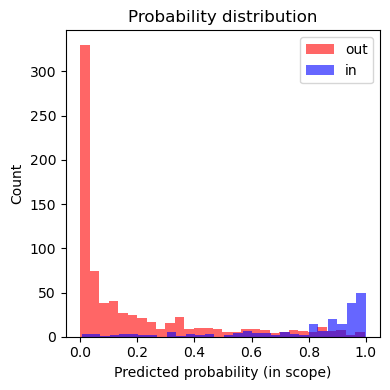

In [41]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(lr_test_proba[y_test_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(lr_test_proba[y_test_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/SPECTER_LR_ProbabilityDistribution.png', dpi=150, bbox_inches='tight')
plt.show()

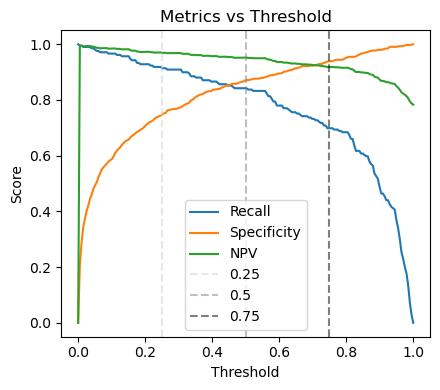

In [42]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    test_pred = (lr_test_proba >= t).astype(int)
    
    TP = ((test_pred == 1) & (y_test_scope == 1)).sum()
    TN = ((test_pred == 0) & (y_test_scope == 0)).sum()
    FP = ((test_pred == 1) & (y_test_scope == 0)).sum()
    FN = ((test_pred == 0) & (y_test_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(4.5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/SPECTER_LR_MetricsThreshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [90]:
# Metrics for threshold T
T = 0.15
pred = (lr_test_proba >= T).astype(int)
    
TP = ((pred == 1) & (y_test_scope == 1)).sum()
TN = ((pred == 0) & (y_test_scope == 0)).sum()
FP = ((pred == 1) & (y_test_scope == 0)).sum()
FN = ((pred == 0) & (y_test_scope == 1)).sum()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
npv = TN / (TN + FN) 

p, c = np.unique(pred, return_counts=True)

print(f"With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(pred) * 100,2)}% of in scope cases.")
print(f"Sensitivity: {sensitivity}, Specificity: {specificity}, NPV: {npv}")

With a threshold of 0.15, we remove 52.34% of all entries and loose ~0.93% of in scope cases.
Sensitivity: 0.9569377990430622, Specificity: 0.656498673740053, NPV: 0.9821428571428571


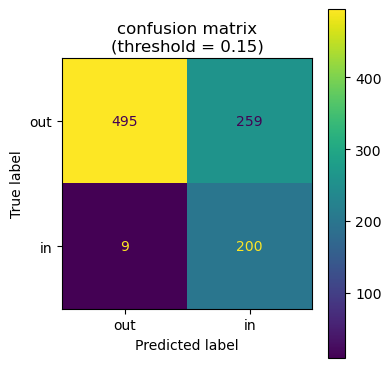

In [114]:
lr_test_preds_015 = (lr_test_proba >= 0.15).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(4,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, lr_test_preds_015),
    display_labels=['out', 'in']
).plot(ax=ax)
ax.set_title('confusion matrix\n(threshold = 0.15)')

plt.tight_layout()
plt.savefig('Plots/SPECTER_LR_T015_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [125]:
# Combine tables with probabilities and predictions for threshold T
T = 0.15

d_train = y_train.copy()
d_train['proba'] = lr_probs
d_train[f'pred_{T}'] = (d_train['proba'] >= T).astype(int)

d_test = y_test.copy()
d_test['proba'] = lr_test_proba
d_test[f'pred_{T}'] = (d_test['proba'] >= T).astype(int)

d = pd.concat([d_train, d_test])

#### Manual check of borderline cases

In [128]:
borderline = [
    "pub.1173257003", "pub.1175524716", "pub.1175608755", "pub.1181848290",
    "pub.1182396222", "pub.1183157921", "pub.1197164068", "pub.1196678028",
    "pub.1196657616", "pub.1196619630", "pub.1196599903", "pub.1196595072",
    "pub.1196580100", "pub.1196485914", "pub.1196249573", "pub.1196064670",
    "pub.1195931632", "pub.1195697981", "pub.1195363103", "pub.1195267885"
]

In [127]:
d[d['id'].isin(borderline)].value_counts(f'pred_{T}')

pred_0.15
1    16
0     1
Name: count, dtype: int64

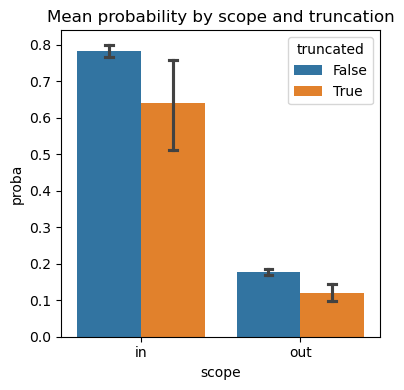

In [92]:
# Check wether truncation during embedding makes a difference
d.groupby(['scope', 'truncated'])['proba'].mean()

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(data=d, x='scope', y='proba', hue='truncated',  capsize=0.1, ax=ax)
ax.set_title('Mean probability by scope and truncation')
plt.tight_layout()
plt.savefig('Plots/SPECTER_LR_T025_truncation.png', dpi=150, bbox_inches='tight')
plt.show()

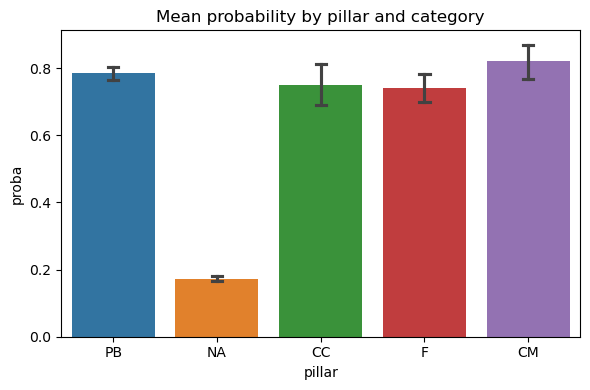

In [93]:
# Check whether different pillars/categories make a difference
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=d, x='pillar', y='proba', hue='pillar', capsize=0.1, ax=ax)
ax.set_title('Mean probability by pillar and category')
plt.tight_layout()
plt.savefig('Plots/SPECTER_LR_Probabilities_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [94]:
lr_fn = d[(d['scope']=='in')  & (d['pred_0.15']==0)]

### SVC

#### Cross validation

In [ ]:
# SVC
svc = CalibratedClassifierCV(SVC(max_iter=1000, class_weight='balanced', C=10, kernel='rbf', gamma=0.001, random_state=42))
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [50]:
# fit model
svc.fit(X_train, y_train_scope)

# Run cross-validation on subset of data
results_svc = cross_validate(svc, X_train, y_train_scope, cv=cv, scoring=scoring)

c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-

In [51]:
for metric in ['precision', 'recall', 'specificity', 'npv', 'f1']:
    scores = results_svc[f'test_{metric}']
    print(f"{metric:12s}: {scores.mean():.3f} ± {scores.std():.3f}")

precision   : 0.814 ± 0.023
recall      : 0.712 ± 0.041
specificity : 0.955 ± 0.007
npv         : 0.923 ± 0.010
f1          : 0.759 ± 0.026


In [52]:
# Get prediction (out of fold)
svc_probs = cross_val_predict(svc, X_train, y_train_scope, 
                              cv=cv, method='predict_proba')[:, 1]
svc_preds = (svc_probs >= 0.5).astype(int)  # binary at default threshold

c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-

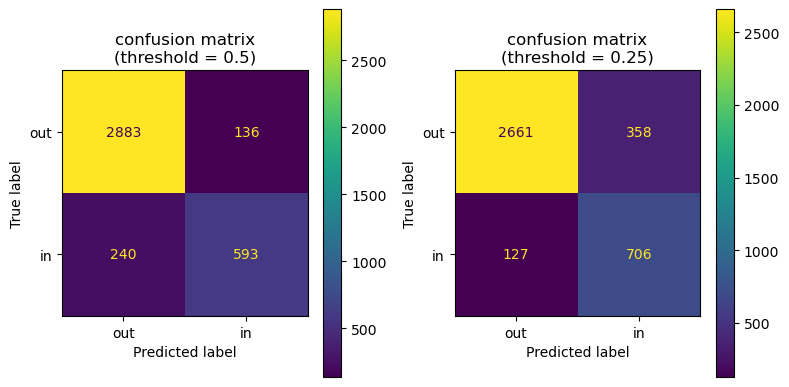

In [53]:
svc_preds_05 = (svc_probs >= 0.5).astype(int)  # binary at default threshold
svc_preds_025 = (svc_probs >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, svc_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, svc_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.show()

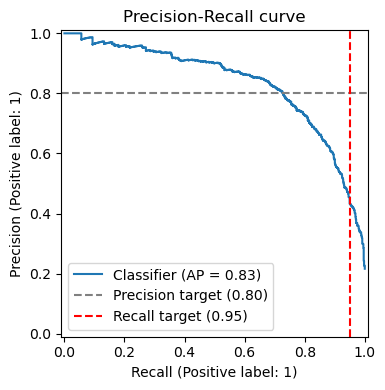

In [54]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_train_scope, svc_probs, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.show()

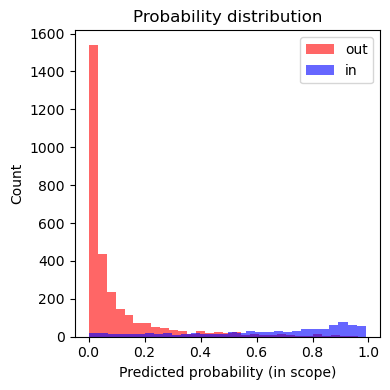

In [55]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(svc_probs[y_train_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(svc_probs[y_train_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.show()

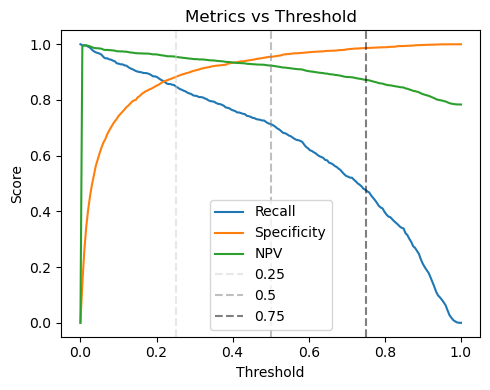

In [56]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    y_pred = (svc_probs >= t).astype(int)
    
    TP = ((y_pred == 1) & (y_train_scope == 1)).sum()
    TN = ((y_pred == 0) & (y_train_scope == 0)).sum()
    FP = ((y_pred == 1) & (y_train_scope == 0)).sum()
    FN = ((y_pred == 0) & (y_train_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
#plt.savefig('threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### Test data

In [57]:
# Test data
svc_test_pred = svc.predict(X_test)
svc_test_proba = svc.predict_proba(X_test)[:, 1]

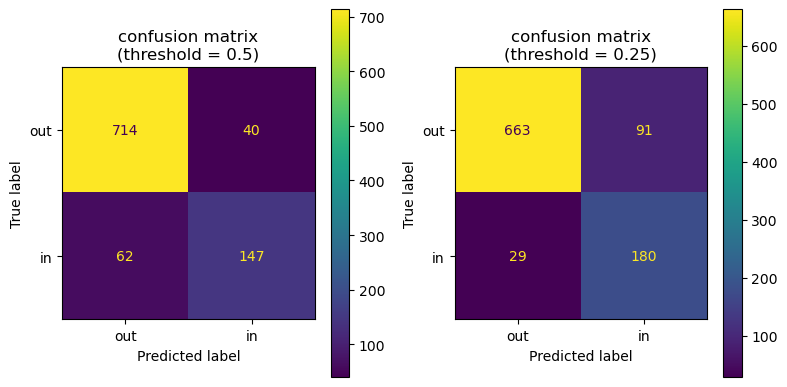

In [58]:
svc_test_preds_05 = (svc_test_proba >= 0.5).astype(int)  # binary at default threshold
svc_test_preds_025 = (svc_test_proba >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, svc_test_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, svc_test_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.savefig('Plots/SPECTER_SVC_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

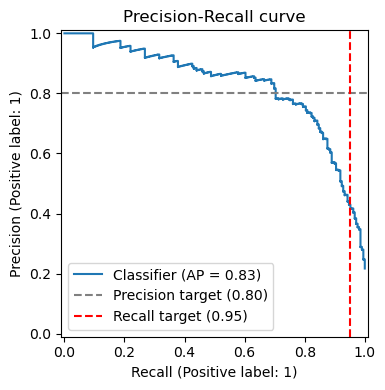

In [59]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_test_scope, svc_test_proba, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/SPECTER_SVC_Precision-Recall.png', dpi=150, bbox_inches='tight')
plt.show()

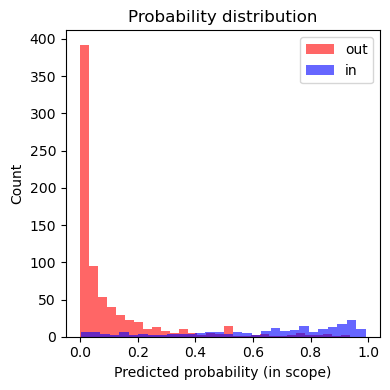

In [60]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(svc_test_proba[y_test_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(svc_test_proba[y_test_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/SPECTER_SVC_ProbabilityDistribution.png', dpi=150, bbox_inches='tight')
plt.show()

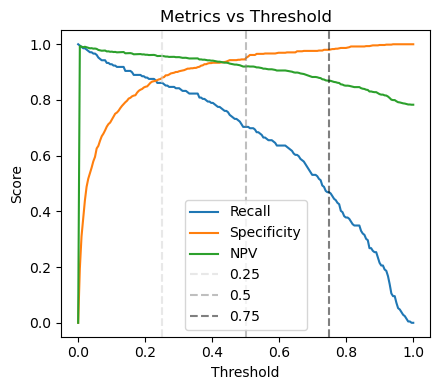

In [61]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    test_pred = (svc_test_proba >= t).astype(int)
    
    TP = ((test_pred == 1) & (y_test_scope == 1)).sum()
    TN = ((test_pred == 0) & (y_test_scope == 0)).sum()
    FP = ((test_pred == 1) & (y_test_scope == 0)).sum()
    FN = ((test_pred == 0) & (y_test_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(4.5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/SPECTER_SVC_MetricsThreshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [119]:
# Metrics for threshold T
T = 0.05
pred = (svc_test_proba >= T).astype(int)
    
TP = ((pred == 1) & (y_test_scope == 1)).sum()
TN = ((pred == 0) & (y_test_scope == 0)).sum()
FP = ((pred == 1) & (y_test_scope == 0)).sum()
FN = ((pred == 0) & (y_test_scope == 1)).sum()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
npv = TN / (TN + FN) 

p, c = np.unique(pred, return_counts=True)

print(f"With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(pred) * 100,2)}% of in scope cases.")
print(f"Sensitivity: {sensitivity}, Specificity: {specificity}, NPV: {npv}")

With a threshold of 0.05, we remove 47.35% of all entries and loose ~0.73% of in scope cases.
Sensitivity: 0.9665071770334929, Specificity: 0.5954907161803713, NPV: 0.9846491228070176


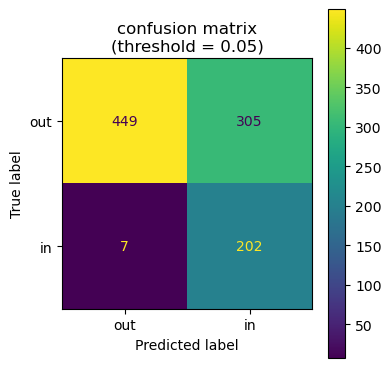

In [121]:
svc_test_preds_005 = (svc_test_proba >= 0.05).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(4,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, svc_test_preds_005),
    display_labels=['out', 'in']
).plot(ax=ax)
ax.set_title('confusion matrix\n(threshold = 0.05)')

plt.tight_layout()
plt.savefig('Plots/SPECTER_SVC_T005_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

#### Manual check of borderline cases

In [129]:
# Combine tables with probabilities and predictions for threshold T
T = 0.05

d_train = y_train.copy()
d_train['proba'] = svc_probs
d_train[f'pred_{T}'] = (d_train['proba'] >= T).astype(int)

d_test = y_test.copy()
d_test['proba'] = svc_test_proba
d_test[f'pred_{T}'] = (d_test['proba'] >= T).astype(int)

d = pd.concat([d_train, d_test])

In [130]:
d[d['id'].isin(borderline)].value_counts(f'pred_{T}')

pred_0.05
1    17
Name: count, dtype: int64

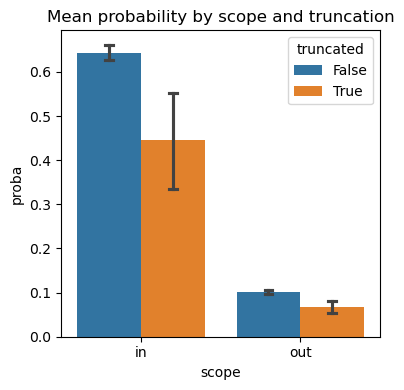

In [100]:
# Check wether truncation during embedding makes a difference
d.groupby(['scope', 'truncated'])['proba'].mean()

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(data=d, x='scope', y='proba', hue='truncated',  capsize=0.1, ax=ax)
ax.set_title('Mean probability by scope and truncation')
plt.tight_layout()
plt.savefig('Plots/SPECTER_SVC_T005_truncation.png', dpi=150, bbox_inches='tight')
plt.show()

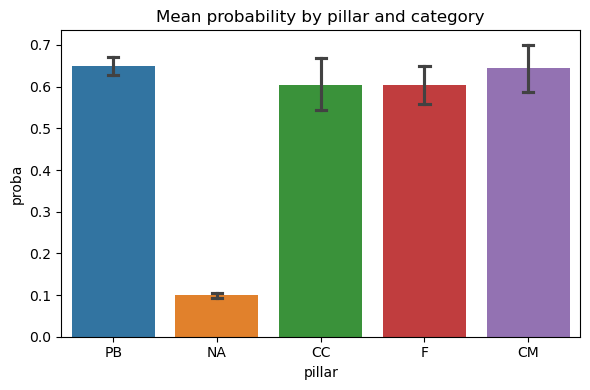

In [101]:
# Check whether different pillars/categories make a difference
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=d, x='pillar', y='proba', hue='pillar', capsize=0.1, ax=ax)
ax.set_title('Mean probability by pillar and category')
plt.tight_layout()
plt.savefig('Plots/SPECTER_SVC_Probabilities_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [102]:
svc_fn = d[(d['scope']=='in')  & (d['pred_0.05']==0)]

### MLP

#### Cross validation

In [ ]:
# MLP
mlp = MLPClassifier(max_iter=1000, early_stopping=True, hidden_layer_sizes=(256,128), learning_rate_init=0.001490, alpha=0.000013, random_state=42)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [69]:
# fit model
mlp.fit(X_train, y_train_scope)

# Run cross-validation on subset of data
mlp_results = cross_validate(mlp, X_train, y_train_scope, cv=cv, scoring=scoring)

In [70]:
for metric in ['precision', 'recall', 'specificity', 'npv', 'f1']:
    scores = mlp_results[f'test_{metric}']
    print(f"{metric:12s}: {scores.mean():.3f} ± {scores.std():.3f}")

precision   : 0.785 ± 0.023
recall      : 0.695 ± 0.036
specificity : 0.947 ± 0.009
npv         : 0.919 ± 0.008
f1          : 0.736 ± 0.018


In [71]:
# Get prediction (out of fold)
mlp_probs = cross_val_predict(mlp, X_train, y_train_scope, 
                              cv=cv, method='predict_proba')[:, 1]
mlp_preds = (mlp_probs >= 0.5).astype(int)  # binary at default threshold


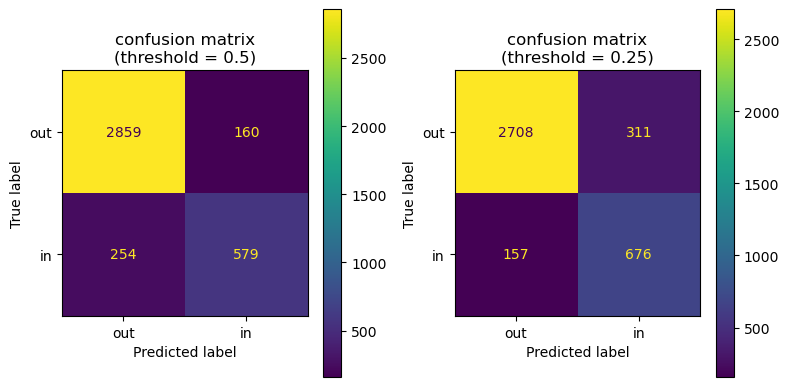

In [72]:
mlp_preds_05 = (mlp_probs >= 0.5).astype(int)  # binary at default threshold
mlp_preds_025 = (mlp_probs >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, mlp_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_train_scope, mlp_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.show()

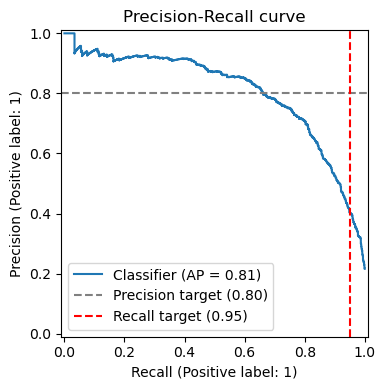

In [73]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_train_scope, mlp_probs, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.show()

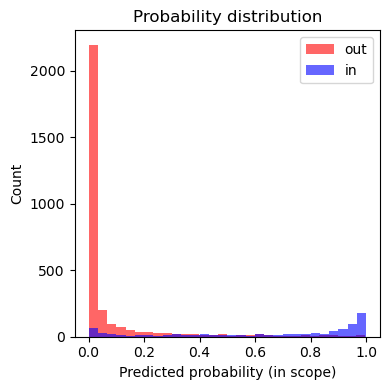

In [74]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(mlp_probs[y_train_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(mlp_probs[y_train_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.show()

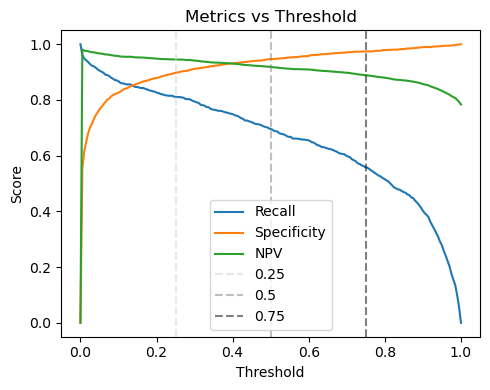

In [75]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    y_pred = (mlp_probs >= t).astype(int)
    
    TP = ((y_pred == 1) & (y_train_scope == 1)).sum()
    TN = ((y_pred == 0) & (y_train_scope == 0)).sum()
    FP = ((y_pred == 1) & (y_train_scope == 0)).sum()
    FN = ((y_pred == 0) & (y_train_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
#plt.savefig('threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### Test data

In [76]:
# Test data
mlp_test_pred = mlp.predict(X_test)
mlp_test_proba = mlp.predict_proba(X_test)[:, 1]

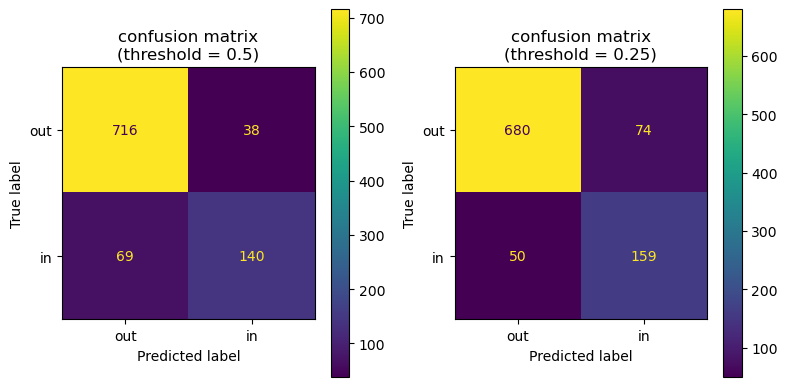

In [77]:
mlp_test_preds_05 = (mlp_test_proba >= 0.5).astype(int)  # binary at default threshold
mlp_test_preds_025 = (mlp_test_proba >= 0.25).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(1,2, figsize=(8,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, mlp_test_preds_05),
    display_labels=['out', 'in']
).plot(ax=ax[0])
ax[0].set_title('confusion matrix\n(threshold = 0.5)')

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, mlp_test_preds_025),
    display_labels=['out', 'in']
).plot(ax=ax[1])
ax[1].set_title('confusion matrix\n(threshold = 0.25)')


plt.tight_layout()
plt.savefig('Plots/SPECTER_MLP_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

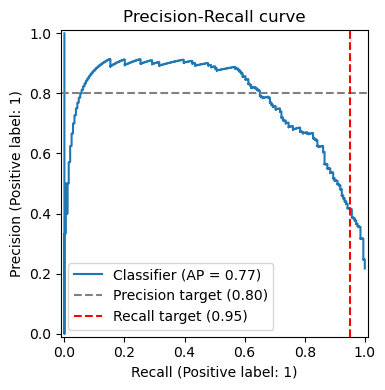

In [78]:
# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(4,4))
PrecisionRecallDisplay.from_predictions(
    y_test_scope, mlp_test_proba, ax=ax
)
ax.axhline(0.80, color='grey',  linestyle='--', label='Precision target (0.80)')
ax.axvline(0.95, color='red',   linestyle='--', label='Recall target (0.95)')
ax.set_title('Precision-Recall curve')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/SPECTER_MLP_Precision-Recall.png', dpi=150, bbox_inches='tight')
plt.show()

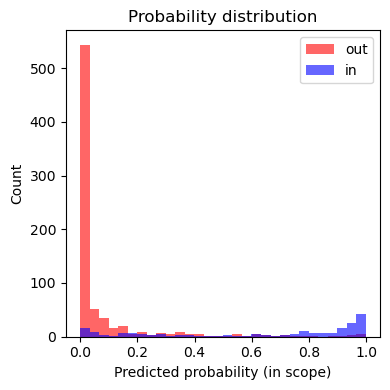

In [79]:
fig, ax = plt.subplots(figsize=(4,4))
ax.hist(mlp_test_proba[y_test_scope == 0], bins=30, alpha=0.6, 
        color='red',  label='out')
ax.hist(mlp_test_proba[y_test_scope == 1], bins=30, alpha=0.6, 
        color='blue', label='in')
ax.set_xlabel('Predicted probability (in scope)')
ax.set_ylabel('Count')
ax.set_title('Probability distribution')
ax.legend()
plt.tight_layout()
plt.savefig('Plots/SPECTER_MLP_ProbabilityDistribution.png', dpi=150, bbox_inches='tight')
plt.show()

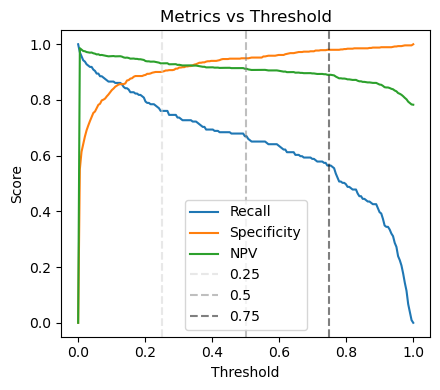

In [80]:
# Plot recall, specificity and npv against different thresholds
thresholds_range = np.linspace(0, 1, 200)

sensitivity = []  # recall / TPR
specificity = []  # TNR
npv         = []  # TN / (TN + FN)

for t in thresholds_range:
    test_pred = (mlp_test_proba >= t).astype(int)
    
    TP = ((test_pred == 1) & (y_test_scope == 1)).sum()
    TN = ((test_pred == 0) & (y_test_scope == 0)).sum()
    FP = ((test_pred == 1) & (y_test_scope == 0)).sum()
    FN = ((test_pred == 0) & (y_test_scope == 1)).sum()
    
    sensitivity.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
    specificity.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    npv.append(        TN / (TN + FN) if (TN + FN) > 0 else 0)

fig, ax = plt.subplots(figsize=(4.5, 4))

# Plot 1: all three metrics vs threshold
ax.plot(thresholds_range, sensitivity, label='Recall')
ax.plot(thresholds_range, specificity, label='Specificity')
ax.plot(thresholds_range, npv,         label='NPV')
ax.axvline(0.25, color='lightgrey', linestyle='--', alpha=0.5, label='0.25')
ax.axvline(0.5, color='grey', linestyle='--', alpha=0.5, label='0.5')
ax.axvline(0.75, color='black', linestyle='--', alpha=0.5, label='0.75')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/SPECTER_MLP_MetricsThreshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [106]:
# Metrics for threshold T
T = 0.01
pred = (mlp_test_proba >= T).astype(int)
    
TP = ((pred == 1) & (y_test_scope == 1)).sum()
TN = ((pred == 0) & (y_test_scope == 0)).sum()
FP = ((pred == 1) & (y_test_scope == 0)).sum()
FN = ((pred == 0) & (y_test_scope == 1)).sum()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
npv = TN / (TN + FN) 

p, c = np.unique(pred, return_counts=True)

print(f"With a threshold of {T}, we remove {round(c[0] / (c[0] + c[1]) * 100, 2)}% of all entries and loose ~{round(FN / len(pred) * 100,2)}% of in scope cases.")
print(f"Sensitivity: {sensitivity}, Specificity: {specificity}, NPV: {npv}")

With a threshold of 0.01, we remove 49.01% of all entries and loose ~0.93% of in scope cases.
Sensitivity: 0.9569377990430622, Specificity: 0.6140583554376657, NPV: 0.9809322033898306


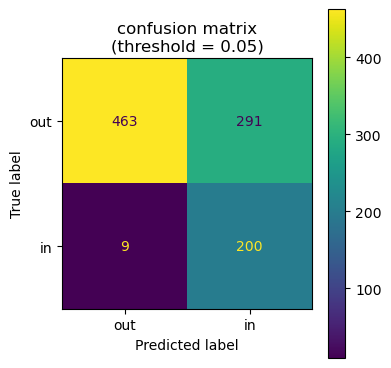

In [123]:
mlp_test_preds_001 = (mlp_test_proba >= 0.01).astype(int)  # binary at default threshold

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(4,4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_scope, mlp_test_preds_001),
    display_labels=['out', 'in']
).plot(ax=ax)
ax.set_title('confusion matrix\n(threshold = 0.05)')

plt.tight_layout()
plt.savefig('Plots/SPECTER_MLP_T001_ConfusionMatrix.png', dpi=150, bbox_inches='tight')
plt.show()

#### Manual check of borderline cases

In [82]:
borderline = [
    "pub.1124225534", "pub.1124559012", "pub.1124752776", "pub.1125171104",
    "pub.1125711840", "pub.1125900690", "pub.1126016358", "pub.1126776207",
    "pub.1127784762", "pub.1128699237", "pub.1128910615", "pub.1128979198",
    "pub.1129074092", "pub.1129500680", "pub.1129501629", "pub.1129666565",
    "pub.1129921272", "pub.1130005418", "pub.1130094430", "pub.1130433231",
    "pub.1130539219", "pub.1131172589", "pub.1131480945", "pub.1131844732",
    "pub.1131885381"
]

In [131]:
# Combine tables with probabilities and predictions for threshold T
T = 0.01

d_train = y_train.copy()
d_train['proba'] = mlp_probs
d_train[f'pred_{T}'] = (d_train['proba'] >= T).astype(int)

d_test = y_test.copy()
d_test['proba'] = mlp_test_proba
d_test[f'pred_{T}'] = (d_test['proba'] >= T).astype(int)

d = pd.concat([d_train, d_test])

In [132]:
d[d['id'].isin(borderline)].value_counts(f'pred_{T}')

pred_0.01
1    17
Name: count, dtype: int64

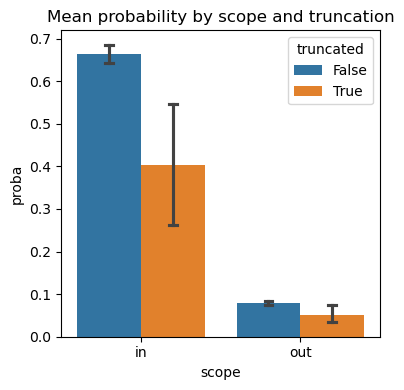

In [108]:
# Check wether truncation during embedding makes a difference
d.groupby(['scope', 'truncated'])['proba'].mean()

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(data=d, x='scope', y='proba', hue='truncated',  capsize=0.1, ax=ax)
ax.set_title('Mean probability by scope and truncation')
plt.tight_layout()
plt.savefig('Plots/SPECTER_MLP_truncation.png', dpi=150, bbox_inches='tight')
plt.show()

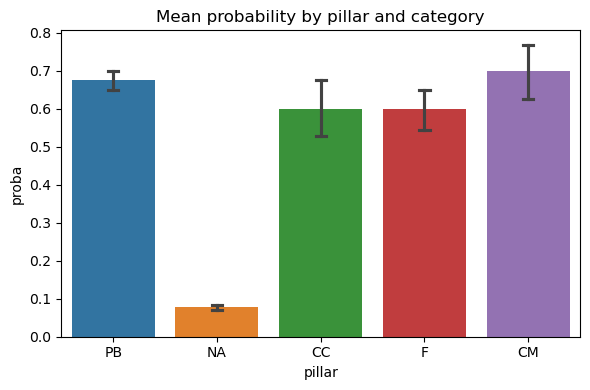

In [109]:
# Check whether different pillars/categories make a difference
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=d, x='pillar', y='proba', hue='pillar', capsize=0.1, ax=ax)
ax.set_title('Mean probability by pillar and category')
plt.tight_layout()
plt.savefig('Plots/SPECTER_MLP_Probabilities_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [110]:
mlp_fn = d[(d['scope']=='in')  & (d['pred_0.01']==0)]

### False Negatives across models

In [111]:
fn = pd.concat([lr_fn[['id', 'title', 'abstract', 'pillar', 'research_category', 'truncated']], 
                svc_fn[['id', 'title', 'abstract', 'pillar', 'research_category', 'truncated']], 
                mlp_fn[['id', 'title', 'abstract', 'pillar', 'research_category', 'truncated']]])

fn = fn.drop_duplicates(subset='id')

fn['LR'] = fn['id'].isin(lr_fn['id'])
fn['SVC'] = fn['id'].isin(svc_fn['id'])
fn['MLP'] = fn['id'].isin(mlp_fn['id'])

fn.to_csv('SPECTER_FalseNegatives.csv')

In [173]:
fn.value_counts(['LR', 'SVC', 'MLP'])

LR     SVC    MLP  
True   True   True     26
       False  False    14
False  False  True     13
True   False  True     11
       True   False     6
False  True   True      2
              False     1
Name: count, dtype: int64

## AP Pillar

In [174]:
# Prepare pillar labels (mark NA's as 'None')
y_train_pillar = y_train['pillar']
y_test_pillar  = y_test['pillar']

pillar_classes = y_train_pillar.unique()

### All entries

In [149]:
# Prepare training
## cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scoring for multiclass
scoring_pillar = {
    'precision': 'precision_macro',
    'recall':    'recall_macro',
    'f1':        'f1_macro'
}

#### Logistic Regression

In [159]:
# Find best LR model
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'solver': ['lbfgs', 'newton-cholesky']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
                    param_grid, cv=cv, scoring=scoring_pillar, refit='recall', n_jobs=-1)
grid.fit(X_train, y_train_scope)
print(grid.best_params_)

{'C': 0.1, 'solver': 'lbfgs'}


In [169]:
lr_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_C', 'param_solver', 
        'mean_test_precision','mean_test_recall', 'mean_test_f1']
lr_grid[cols].sort_values('mean_test_recall', ascending=False)

,param_C,param_solver,mean_test_precision,mean_test_recall,mean_test_f1
0,0.1,lbfgs,0.800717,0.856199,0.821321
1,0.1,newton-cholesky,0.800717,0.856199,0.821321
2,1.0,lbfgs,0.808963,0.848880,0.824966
3,1.0,newton-cholesky,0.808963,0.848880,0.824966
4,10.0,lbfgs,0.797685,0.822205,0.807901
5,10.0,newton-cholesky,0.797685,0.822205,0.807901
6,100.0,lbfgs,0.783993,0.802697,0.791863
7,100.0,newton-cholesky,0.783993,0.802697,0.791863
8,1000.0,lbfgs,0.787270,0.800442,0.792997
9,1000.0,newton-cholesky,0.787270,0.800442,0.792997


In [ ]:
# Logistic Regression
clf_pillar = LogisticRegression(
    C=0.1,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42 
)

In [150]:
# Cross-validation
lr_results_pillar = cross_validate(clf_pillar, X_train, y_train_pillar, cv=cv, scoring=scoring_pillar)
lr_results_pillar

{'fit_time': array([2.54338288, 1.8034544 , 1.95335412, 2.30293274, 2.19599962]),
 'score_time': array([0.03306389, 0.03217316, 0.02767563, 0.03029823, 0.03126192]),
 'test_precision': array([0.58755179, 0.60223398, 0.58659864, 0.52918735, 0.5632478 ]),
 'test_recall': array([0.6940994 , 0.79325219, 0.74394881, 0.69031967, 0.68687282]),
 'test_f1': array([0.62578873, 0.67120129, 0.64688949, 0.58560438, 0.60002575])}

In [151]:
# Fit model
clf_pillar.fit(X_train, y_train_pillar)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [213]:
# Predict training (cross validation)
lr_pred_pillar = cross_val_predict(clf_pillar, X_train, y_train_pillar)
lr_proba_pillar = cross_val_predict(clf_pillar, X_train, y_train_pillar, method='predict_proba')[:, 1]


In [171]:
# Predict test dataset
lr_pillar_test_pred = clf_pillar.predict(X_test)
lr_pillar_test_proba = clf_pillar.predict_proba(X_test)[:, 1]

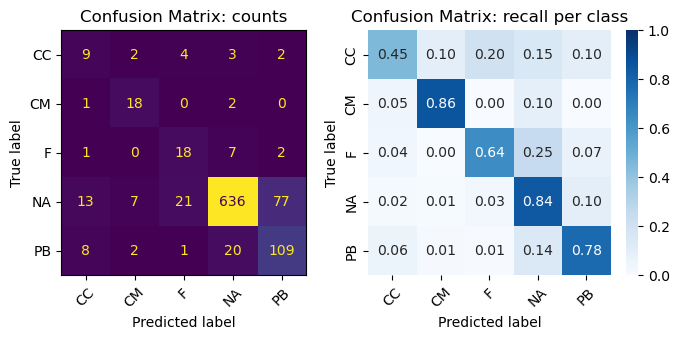

In [198]:
# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), gridspec_kw={'width_ratios': [1, 1.2]})

# Plot 1: Raw counts confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    y_test_pillar, lr_pillar_test_pred,
    display_labels=clf_pillar.classes_,
    ax=axes[0],
    colorbar=False,
    xticks_rotation=45
)
axes[0].set_title('Confusion Matrix: counts')

# Plot 2: Normalised confusion matrix 
cm_norm = confusion_matrix(y_test_pillar, lr_pillar_test_pred, labels=clf_pillar.classes_, normalize='true')

sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f',
    xticklabels=clf_pillar.classes_,
    yticklabels=clf_pillar.classes_,
    cmap='Blues',
    vmin=0, vmax=1,
    ax=axes[1]
)
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')
axes[1].set_title('Confusion Matrix: recall per class')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Plots/SPECTER_LR_ConfusionMatrix_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [261]:
# Combine tables with probabilities and predictions for threshold T
T = 0.15

d_train = y_train.copy()
d_train['proba_scope'] = lr_probs
d_train['pred_scope'] = (d_train['proba_scope'] >= T).astype(int)
d_train['proba_pillar'] = lr_proba_pillar
d_train['pred_pillar'] = lr_pred_pillar

d_test = y_test.copy()
d_test['proba_scope'] = lr_test_proba
d_test['pred_scope'] = (d_test['proba_scope'] >= T).astype(int)
d_test['proba_pillar'] = lr_pillar_test_proba
d_test['pred_pillar'] = lr_pillar_test_pred

d_lr = pd.concat([d_train, d_test])
d_lr['Threshold_scope'] = T

In [ ]:
d_lr

### SVC

In [200]:
# Test hyperparameters of Support Vector Classification model
param_grid = {
    'estimator__C':     [1, 10, 100, 1000],
    'estimator__gamma': [0.001, 0.01],
    'estimator__kernel': ['linear', 'rbf']
}

# CalibratedClasssifierCV wrapper to get calibrated probabilities
calibrated_svc = CalibratedClassifierCV(
    SVC(class_weight='balanced'),
    cv=cv,
    ensemble=False
)

grid = GridSearchCV(calibrated_svc, param_grid, cv=cv, scoring=scoring_pillar, refit='f1', n_jobs=-1)
grid.fit(X_train, y_train_pillar)
print(grid.best_params_)

{'estimator__C': 100, 'estimator__gamma': 0.001, 'estimator__kernel': 'rbf'}


In [ ]:
# save results to data frame
svc_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_estimator__C', 'param_estimator__gamma', 'param_estimator__kernel', 
        'mean_test_precision','mean_test_recall', 'mean_test_f1']
svc_grid[cols].sort_values('mean_test_recall', ascending=False)

In [205]:
# SVC
svc_pillar = CalibratedClassifierCV(
    SVC(max_iter=1000, 
        class_weight='balanced', 
        C=100, kernel='rbf',
        gamma=0.001, 
        random_state=42))

In [ ]:
# Cross-validation
svc_results_pillar = cross_validate(svc_pillar, X_train, y_train_pillar, cv=cv, scoring=scoring_pillar)
svc_results_pillar

In [ ]:
# Fit model
svc_pillar = svc_pillar.fit(X_train, y_train_pillar)

In [ ]:
# Get training predictions
# Predict training (cross validation)
svc_pred_pillar = cross_val_predict(svc_pillar, X_train, y_train_pillar)
svc_proba_pillar = cross_val_predict(svc_pillar, X_train, y_train_pillar, method='predict_proba')[:, 1]

In [209]:
# Get test data predictions
svc_pillar_test_pred = svc_pillar.predict(X_test)
svc_pillar_test_proba = svc_pillar.predict_proba(X_test)[:, 1]

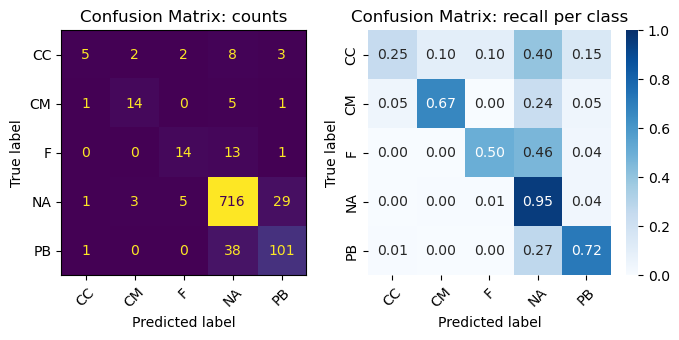

In [323]:
# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), gridspec_kw={'width_ratios': [1, 1.2]})

# Plot 1: Raw counts confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    y_test_pillar, svc_pillar_test_pred,
    display_labels=svc_pillar.classes_,
    ax=axes[0],
    colorbar=False,
    xticks_rotation=45
)
axes[0].set_title('Confusion Matrix: counts')

# Plot 2: Normalised confusion matrix 
cm_norm = confusion_matrix(y_test_pillar, svc_pillar_test_pred, labels=svc_pillar.classes_, normalize='true')

sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f',
    xticklabels=svc_pillar.classes_,
    yticklabels=svc_pillar.classes_,
    cmap='Blues',
    vmin=0, vmax=1,
    ax=axes[1]
)
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')
axes[1].set_title('Confusion Matrix: recall per class')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Plots/SPECTER_SVC_ConfusionMatrix_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [260]:
# Combine tables with probabilities and predictions for threshold T
T = 0.05

d_train = y_train.copy()
d_train['proba_scope'] = svc_probs
d_train['pred_scope'] = (d_train['proba_scope'] >= T).astype(int)
d_train['proba_pillar'] = svc_proba_pillar
d_train['pred_pillar'] = svc_pred_pillar

d_test = y_test.copy()
d_test['proba_scope'] = svc_test_proba
d_test['pred_scope'] = (d_test['proba_scope'] >= T).astype(int)
d_test['proba_pillar'] = svc_pillar_test_proba
d_test['pred_pillar'] = svc_pillar_test_pred

d_svc = pd.concat([d_train, d_test])
d_svc['Threshold_scope'] = T

### MLP

In [216]:
# Test hyperparameters of Multi-Layer Perceptron model
param_dist = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (256, 128)],
    'alpha': [0.00001, 0.0001, 0.001, 0.01],
    'learning_rate_init': [0.00001, 0.0001, 0.001, 0.01],
    'solver': ['lbfgs', 'adam']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = RandomizedSearchCV(
    MLPClassifier(early_stopping=True, random_state=42, max_iter=1000),
    param_distributions=param_dist,
    n_iter=100,
    scoring=scoring_pillar,
    refit='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

grid.fit(X_train, y_train_pillar)
print(grid.best_params_)

c:\Users\Public\miniconda3\envs\sheep_copy\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 96 is smaller than n_iter=100. Running 96 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 96 candidates, totalling 480 fits
{'solver': 'lbfgs', 'learning_rate_init': 1e-05, 'hidden_layer_sizes': (128, 64), 'alpha': 0.0001}


In [220]:
# save results to data frame
mlp_grid = pd.DataFrame(grid.cv_results_)

cols = ['param_hidden_layer_sizes', 'param_learning_rate_init', 'param_alpha', 'param_solver',
        'mean_test_precision', 'mean_test_recall',  'mean_test_f1']

mlp_grid[cols].sort_values('mean_test_f1', ascending=False)


,param_hidden_layer_sizes,param_learning_rate_init,param_alpha,param_solver,mean_test_precision,mean_test_recall,mean_test_f1
15,"(128, 64)",0.01000,0.00001,adam,0.729038,0.642610,0.675226
69,"(256, 128)",0.00100,0.00100,adam,0.737714,0.621126,0.663622
32,"(128, 64)",0.00001,0.00010,lbfgs,0.679525,0.645428,0.658566
38,"(128, 64)",0.01000,0.00010,lbfgs,0.679525,0.645428,0.658566
34,"(128, 64)",0.00010,0.00010,lbfgs,0.679525,0.645428,0.658566
...,...,...,...,...,...,...,...
49,"(64, 32)",0.00001,0.00100,adam,0.302438,0.274833,0.279927
9,"(128, 64)",0.00001,0.00001,adam,0.395172,0.265600,0.275116
33,"(128, 64)",0.00001,0.00010,adam,0.395172,0.265600,0.275116
57,"(128, 64)",0.00001,0.00100,adam,0.395172,0.265600,0.275116


In [221]:
# MLP
mlp_pillar = MLPClassifier(
    max_iter=1000, 
    early_stopping=True, 
    hidden_layer_sizes=(128,64), 
    solver='adam',
    learning_rate_init=0.01, 
    alpha=0.00001, 
    random_state=42)

In [222]:
# Cross-validation
mlp_results_pillar = cross_validate(mlp_pillar, X_train, y_train_pillar, cv=cv, scoring=scoring_pillar)
mlp_results_pillar

{'fit_time': array([1.95678091, 1.1692121 , 1.94714832, 1.3487606 , 1.47775245]),
 'score_time': array([0.03496718, 0.01314425, 0.02978086, 0.03282118, 0.03168654]),
 'test_precision': array([0.70867957, 0.7662672 , 0.70494778, 0.68648518, 0.77881139]),
 'test_recall': array([0.64553204, 0.66435699, 0.72386123, 0.56809582, 0.61120506]),
 'test_f1': array([0.67295349, 0.70751082, 0.70720634, 0.61708898, 0.67137094])}

In [223]:
# Fit model
mlp_pillar = mlp_pillar.fit(X_train, y_train_pillar)

In [224]:
# Get training predictions
# Predict training (cross validation)
mlp_pred_pillar = cross_val_predict(mlp_pillar, X_train, y_train_pillar)
mlp_proba_pillar = cross_val_predict(mlp_pillar, X_train, y_train_pillar, method='predict_proba')[:, 1]

In [225]:
# Get test data predictions
mlp_pillar_test_pred = mlp_pillar.predict(X_test)
mlp_pillar_test_proba = mlp_pillar.predict_proba(X_test)[:, 1]

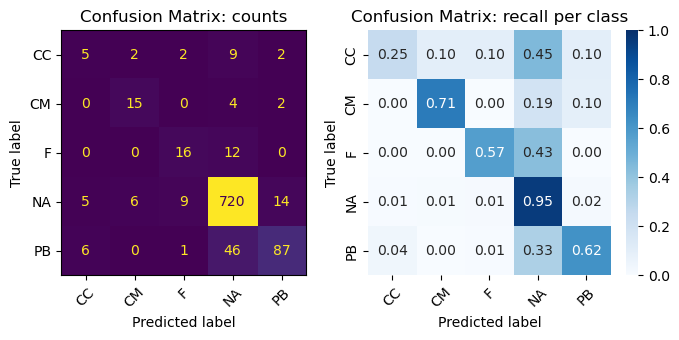

In [226]:
# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), gridspec_kw={'width_ratios': [1, 1.2]})

# Plot 1: Raw counts confusion matrix 
ConfusionMatrixDisplay.from_predictions(
    y_test_pillar, mlp_pillar_test_pred,
    display_labels=mlp_pillar.classes_,
    ax=axes[0],
    colorbar=False,
    xticks_rotation=45
)
axes[0].set_title('Confusion Matrix: counts')

# Plot 2: Normalised confusion matrix 
cm_norm = confusion_matrix(y_test_pillar, mlp_pillar_test_pred, labels=mlp_pillar.classes_, normalize='true')

sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f',
    xticklabels=mlp_pillar.classes_,
    yticklabels=mlp_pillar.classes_,
    cmap='Blues',
    vmin=0, vmax=1,
    ax=axes[1]
)
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')
axes[1].set_title('Confusion Matrix: recall per class')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('Plots/SPECTER_MLP_ConfusionMatrix_Pillar.png', dpi=150, bbox_inches='tight')
plt.show()

In [259]:
# Combine tables with probabilities and predictions for threshold T
T = 0.01

d_train = y_train.copy()
d_train['proba_scope'] = mlp_probs
d_train['pred_scope'] = (d_train['proba_scope'] >= T).astype(int)
d_train['proba_pillar'] = mlp_proba_pillar
d_train['pred_pillar'] = mlp_pred_pillar

d_test = y_test.copy()
d_test['proba_scope'] = mlp_test_proba
d_test['pred_scope'] = (d_test['proba_scope'] >= T).astype(int)
d_test['proba_pillar'] = mlp_pillar_test_proba
d_test['pred_pillar'] = mlp_pillar_test_pred

d_mlp = pd.concat([d_train, d_test])
d_mlp['Threshold_scope'] = T

## Comparison

### Plot threshold vs. exclusion

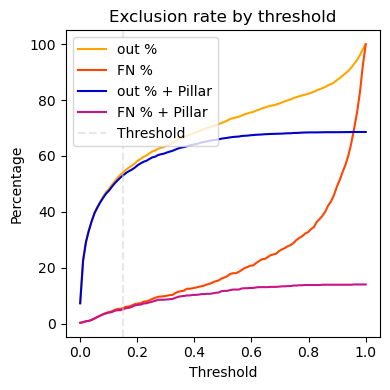

In [318]:
# LR
# Plot development of exclusion ratio vs. threshold
# data used here: training (cross-validated) and test data 
tmp = d_lr.copy()
T = d_lr['Threshold_scope'].unique()
exclusion = []
for i in (np.linspace(0.001, 1, 100)):
    tmp['pred_i'] = (tmp['proba_scope'] >= i).astype(int)
    tmp['pred_combined'] = ((tmp['pred_pillar'] != 'NA') | tmp['pred_i'] == 1).astype(int)
    r = len(tmp[tmp['pred_i'] == 0]) / len(tmp) * 100
    r_fn = len(tmp[(tmp['pred_i'] == 0) & (tmp['scope'] == 'in')]) / len(tmp[tmp['scope'] == 'in']) * 100
    r_comb = len(tmp[tmp['pred_combined'] == 0]) / len(tmp) * 100
    r_fn_comb = len(tmp[(tmp['pred_combined'] == 0) & (tmp['scope'] == 'in')]) / len(tmp[tmp['scope'] == 'in']) * 100
    exclusion.append([i, r, r_fn, r_comb, r_fn_comb])

excl_df = pd.DataFrame(exclusion, columns=['threshold', 'ratio_out', 'ratio_FN', 'ratio_out_comb', 'ratio_FN_comb'])

fig, ax = plt.subplots(figsize=(4, 4))

# Plot 1: all three metrics vs threshold
ax.plot(excl_df['threshold'], excl_df['ratio_out'], label='out %', color='orange')
ax.plot(excl_df['threshold'], excl_df['ratio_FN'], label='FN %', color='orangered')
ax.plot(excl_df['threshold'], excl_df['ratio_out_comb'], label='out % + Pillar', color='mediumblue')
ax.plot(excl_df['threshold'], excl_df['ratio_FN_comb'], label='FN % + Pillar', color='mediumvioletred')

ax.axvline(T, color='lightgrey', linestyle='--', alpha=0.5, label='Threshold')

ax.set_xlabel('Threshold')
ax.set_ylabel('Percentage')
ax.set_title('Exclusion rate by threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/SPECTER_LR_Exclusion_Threshold.png', dpi=150, bbox_inches='tight')
plt.show()

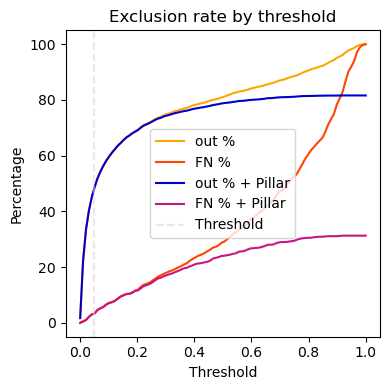

In [319]:
# SVC
# Plot development of exclusion ratio vs. threshold
# data used here: training (cross-validated) and test data 
tmp = d_svc.copy()
T = d_svc['Threshold_scope'].unique()
exclusion = []
for i in (np.linspace(0.001, 1, 100)):
    tmp['pred_i'] = (tmp['proba_scope'] >= i).astype(int)
    tmp['pred_combined'] = ((tmp['pred_pillar'] != 'NA') | tmp['pred_i'] == 1).astype(int)
    r = len(tmp[tmp['pred_i'] == 0]) / len(tmp) * 100
    r_fn = len(tmp[(tmp['pred_i'] == 0) & (tmp['scope'] == 'in')]) / len(tmp[tmp['scope'] == 'in']) * 100
    r_comb = len(tmp[tmp['pred_combined'] == 0]) / len(tmp) * 100
    r_fn_comb = len(tmp[(tmp['pred_combined'] == 0) & (tmp['scope'] == 'in')]) / len(tmp[tmp['scope'] == 'in']) * 100
    exclusion.append([i, r, r_fn, r_comb, r_fn_comb])

excl_df = pd.DataFrame(exclusion, columns=['threshold', 'ratio_out', 'ratio_FN', 'ratio_out_comb', 'ratio_FN_comb'])

fig, ax = plt.subplots(figsize=(4, 4))

# Plot 1: all three metrics vs threshold
ax.plot(excl_df['threshold'], excl_df['ratio_out'], label='out %', color='orange')
ax.plot(excl_df['threshold'], excl_df['ratio_FN'], label='FN %', color='orangered')
ax.plot(excl_df['threshold'], excl_df['ratio_out_comb'], label='out % + Pillar', color='mediumblue')
ax.plot(excl_df['threshold'], excl_df['ratio_FN_comb'], label='FN % + Pillar', color='mediumvioletred')

ax.axvline(T, color='lightgrey', linestyle='--', alpha=0.5, label='Threshold')

ax.set_xlabel('Threshold')
ax.set_ylabel('Percentage')
ax.set_title('Exclusion rate by threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/SPECTER_SVC_Exclusion_Threshold.png', dpi=150, bbox_inches='tight')
plt.show()

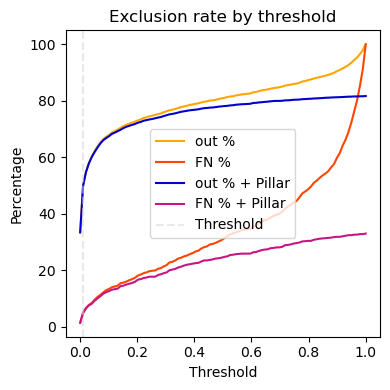

In [322]:
# MLP
# Plot development of exclusion ratio vs. threshold
# data used here: training (cross-validated) and test data 
tmp = d_mlp.copy()
T = d_mlp['Threshold_scope'].unique()
exclusion = []
for i in (np.linspace(0.001, 1, 100)):
    tmp['pred_i'] = (tmp['proba_scope'] >= i).astype(int)
    tmp['pred_combined'] = ((tmp['pred_pillar'] != 'NA') | tmp['pred_i'] == 1).astype(int)
    r = len(tmp[tmp['pred_i'] == 0]) / len(tmp) * 100
    r_fn = len(tmp[(tmp['pred_i'] == 0) & (tmp['scope'] == 'in')]) / len(tmp[tmp['scope'] == 'in']) * 100
    r_comb = len(tmp[tmp['pred_combined'] == 0]) / len(tmp) * 100
    r_fn_comb = len(tmp[(tmp['pred_combined'] == 0) & (tmp['scope'] == 'in')]) / len(tmp[tmp['scope'] == 'in']) * 100
    exclusion.append([i, r, r_fn, r_comb, r_fn_comb])

excl_df = pd.DataFrame(exclusion, columns=['threshold', 'ratio_out', 'ratio_FN', 'ratio_out_comb', 'ratio_FN_comb'])

fig, ax = plt.subplots(figsize=(4, 4))

# Plot 1: all three metrics vs threshold
ax.plot(excl_df['threshold'], excl_df['ratio_out'], label='out %', color='orange')
ax.plot(excl_df['threshold'], excl_df['ratio_FN'], label='FN %', color='orangered')
ax.plot(excl_df['threshold'], excl_df['ratio_out_comb'], label='out % + Pillar', color='mediumblue')
ax.plot(excl_df['threshold'], excl_df['ratio_FN_comb'], label='FN % + Pillar', color='mediumvioletred')

ax.axvline(T, color='lightgrey', linestyle='--', alpha=0.5, label='Threshold')

ax.set_xlabel('Threshold')
ax.set_ylabel('Percentage')
ax.set_title('Exclusion rate by threshold')
ax.legend()

plt.tight_layout()
plt.savefig('Plots/SPECTER_MLP_Exclusion_Threshold.png', dpi=150, bbox_inches='tight')
plt.show()

### Close connection

In [112]:
db.close()